# Combat Simulator

This notebook calculates monte carlo combat simulations based on the pre-computed odds cache.

In [1]:
import numpy as np

# --- GENERATE STATIC ODDS CACHE ---
ODDS_CACHE = {}

for num_dice in range(1, 11):
    ODDS_CACHE[num_dice] = {}
    for target in range(2, 21):
        ODDS_CACHE[num_dice][target] = {'exact': [], 'cumulative': [], 'stats': {}}
        
        p_0 = (20 - target) / 20.0
        p_1 = (target - 1) / 20.0
        p_2 = 1.0 / 20.0
        
        single_die = np.array([p_0, p_1, p_2])
        poly = np.polynomial.polynomial.polypow(single_die, num_dice)
        
        percentages = poly * 100
        
        # Calculate up to theoretical 20 max successes
        cumul_list = []
        for s in range(21):
            chance_exact = percentages[s] if s < len(percentages) else 0.0
            chance_cumul = np.sum(percentages[s:]) if s < len(percentages) else 0.0
            
            ODDS_CACHE[num_dice][target]['exact'].append(round(chance_exact, 2))
            
            if s == 0:
                ODDS_CACHE[num_dice][target]['cumulative'].append(round(chance_exact, 2))
            else:
                ODDS_CACHE[num_dice][target]['cumulative'].append(round(chance_cumul, 2))
            
            cumul_list.append(chance_cumul)
            
        # Calculate stats
        # The raw exact float average
        raw_avg = sum(s * (p/100) for s, p in enumerate(percentages))
        # Python's built-in round() rounds x.5 to the nearest EVEN integer. 
        # To round traditional x.5 up to x+1, we add a tiny epsilon.
        avg_success = int(round(raw_avg + 0.000001))
        
        idx_75 = min(range(21), key=lambda i: abs(cumul_list[i] - 75.0))
        idx_25 = min(range(21), key=lambda i: abs(cumul_list[i] - 25.0))
        
        ODDS_CACHE[num_dice][target]['stats'] = {'avg': avg_success, 'p75': idx_75, 'p25': idx_25, 'raw_avg': raw_avg}

print("✅ ODDS_CACHE generated successfully in memory.")

✅ ODDS_CACHE generated successfully in memory.


***
## 5. Combat Simulator (1 vs X Monte Carlo)
This tool simulates head-to-head combat between Player and an array of target Monsters. It runs sequential turns until either the Player dies, or all Monsters die.

**Turn Logic:**
- Player targets the FIRST alive monster in the array (Priority target).
- ALL alive monsters attack the player simultaneously on their turn.

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def simulate_combat_1vx(player, monsters_list, num_simulations=10000):
    """
    player: dict e.g. {'name': 'Player', 'dice': 3, 'target': 13, 'damage': 4, 'health': 40}
    monsters_list: list of dicts e.g. [{'name': 'Goblin', 'dice': 2, 'target': 8, 'damage': 2, 'health': 10}, ...]
    Simulates a 1 vs X combat. Player attacks the first alive monster. 
    All alive monsters attack the player.
    Simulation runs twice: 
       Scenario 1: Player acts first (Player hits, then all alive monsters hit)
       Scenario 2: Monsters act first (All alive monsters hit, then player hits)
    """
    
    def get_roll_probs(dice, target):
        # Handle bounds just in case
        dice = max(1, min(10, dice))
        target = max(2, min(20, target))
        
        probs = np.array(ODDS_CACHE[dice][target]['exact']) / 100.0
        probs = probs / probs.sum()
        return probs
        
    probs_p = get_roll_probs(player['dice'], player['target'])
    
    outcomes = []
    
    # For multi-monster combat, we need probability arrays for every monster
    m_probs_list = [get_roll_probs(m['dice'], m['target']) for m in monsters_list]
    
    for player_goes_first in [True, False]:
        scenario_name = f"Player Attacks First" if player_goes_first else f"Monsters Attack First"
        
        health_p = np.full(num_simulations, float(player['health']))
        
        # Health array for each monster: shape (num_monsters, num_simulations)
        num_m = len(monsters_list)
        health_m = np.zeros((num_m, num_simulations))
        for i, m in enumerate(monsters_list):
            health_m[i, :] = m['health']
            
        # Randomize target priorities per simulation
        # This creates an array of shape (num_monsters, num_simulations)
        # where each column is a completely random permutation of indices [0, 1, 2...]
        priority_matrix = np.zeros((num_m, num_simulations), dtype=int)
        for sim_idx in range(num_simulations):
            priority_matrix[:, sim_idx] = np.random.permutation(num_m)
            
        active_fights = np.ones(num_simulations, dtype=bool)
        
        turn_is_player = player_goes_first
        
        while np.any(active_fights):
            num_active = np.sum(active_fights)
            
            if turn_is_player:
                # Player attacks a monster
                successes = np.random.choice(len(probs_p), size=num_active, p=probs_p)
                damage = successes * player['damage']
                
                # Determine the player's randomly assigned target for EACH individual active fight
                # m_alive tracks boolean [True, False, True] states column by column
                m_alive = health_m[:, active_fights] > 0
                
                # We mask out dead monsters from the priority matrix by assigning them a priority of -1
                # Since priority_matrix holds ranks (e.g., 0 is highest priority, 1 is next), 
                # we only want to look at priorities where the monster is actually alive.
                active_priorities = priority_matrix[:, active_fights]
                
                # To easily find the "alive monster with the lowest priority rank (highest importance)",
                # we give dead monsters an artificially massive priority number so they never get picked.
                masked_priorities = np.where(m_alive, active_priorities, 9999)
                
                # Find the index of the monster with the lowest valid priority number in each fight column
                target_indices = np.argmin(masked_priorities, axis=0)
                
                # Apply damage to the targeted monster across all active fights simultaneously
                target_row = target_indices
                target_col = np.arange(num_active)
                
                active_monster_health = health_m[:, active_fights]
                active_monster_health[target_row, target_col] -= damage
                health_m[:, active_fights] = active_monster_health
                
            else:
                # Monsters attack player
                # ONLY alive monsters attack
                total_damage_to_player = np.zeros(num_active)
                
                for i, m in enumerate(monsters_list):
                    # Which active fights have THIS specific monster still alive?
                    m_is_alive_in_fight = health_m[i, active_fights] > 0
                    num_m_alive = np.sum(m_is_alive_in_fight)
                    
                    if num_m_alive > 0:
                        successes = np.random.choice(len(m_probs_list[i]), size=num_m_alive, p=m_probs_list[i])
                        dmg = successes * m['damage']
                        
                        # Add to the running total of damage for this specific subset of fights
                        total_damage_to_player[m_is_alive_in_fight] += dmg
                        
                health_p[active_fights] -= total_damage_to_player
                
            # Update active fights: Player must be alive, AND at least one monster must be alive
            player_alive = health_p > 0
            any_monsters_alive = np.any(health_m > 0, axis=0)
            active_fights = player_alive & any_monsters_alive
            
            turn_is_player = not turn_is_player
            
        # Win tracking
        p_won_mask = health_p > 0
        p_win_pct = np.sum(p_won_mask) / num_simulations * 100
        
        # Record ONLY player health for the boxplot
        for hp in health_p[p_won_mask]:
            outcomes.append({'Scenario': scenario_name, 'Winner': player['name'], 'Remaining HP': hp})
            
        # Keep track of win percents in a global dict so we can build the tables
        outcomes.append({'Scenario': scenario_name, 'Winner': 'WIN_PCT_STORE', 'Remaining HP': p_win_pct})
            
    df = pd.DataFrame(outcomes)
    
    # ==========================================
    # VISUALIZATION
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [1, 2.5]})
    fig.suptitle(f"1 vs {num_m} Combat ({num_simulations:,} simulated fights)", fontsize=16, weight='bold', y=1.05)
    
    ax_text = axes[0]
    ax_box = axes[1]
    
    ax_text.axis('off')
    
    # Grab the Win Pct storage points
    pct_p_first = df[(df['Scenario'] == 'Player Attacks First') & (df['Winner'] == 'WIN_PCT_STORE')]['Remaining HP'].values[0]
    pct_m_first = df[(df['Scenario'] == 'Monsters Attack First') & (df['Winner'] == 'WIN_PCT_STORE')]['Remaining HP'].values[0]
    
    # Filter the DataFrame to ONLY player points for the boxplot
    box_df = df[df['Winner'] == player['name']]
    
    col_labels = ["Scenario", "Player Win %"]
    cell_text = [
        ["Player Initial", f"{pct_p_first:05.2f}%"],
        ["Monster Initial", f"{pct_m_first:05.2f}%"]
    ]
    
    table = ax_text.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2.8) 
    
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e6e6e6')
            
    sns.boxplot(
        data=box_df, 
        y='Scenario', 
        x='Remaining HP', 
        ax=ax_box, 
        orient='h', 
        color='#4d94ff',
        order=['Player Attacks First', 'Monsters Attack First']
    )
    
    ax_box.set_ylabel('')
    ax_box.set_yticks([])  # Let the table labels act as the visual guide
    ax_box.set_title(f"Distribution of {player['name']}'s Remaining Player HP on Victory")
    ax_box.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()



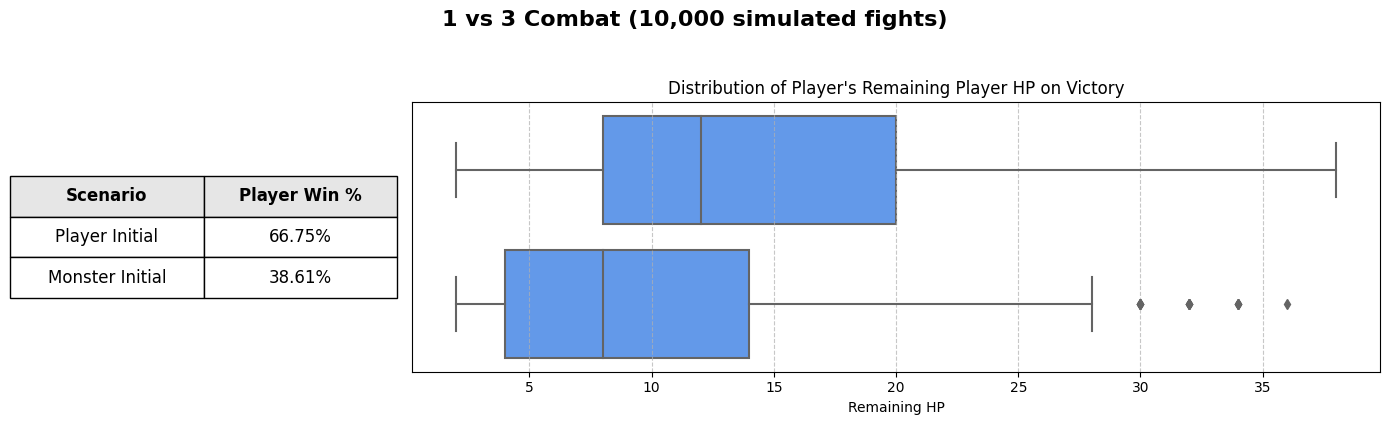

In [8]:
# --- CONFIGURE YOUR ENCOUNTER HERE ---
player = {'name': 'Player', 'dice': 3, 'target': 13, 'damage': 4, 'health': 40}

# Array of monsters. The player will always attack index 0 until it dies, then index 1, etc.
monsters = [
    {'name': 'Goblin A', 'dice': 2, 'target': 8, 'damage': 2, 'health': 10},
    {'name': 'Goblin B', 'dice': 2, 'target': 8, 'damage': 2, 'health': 10},
    {'name': 'Goblin Boss', 'dice': 3, 'target': 10, 'damage': 4, 'health': 20}
]

# Run 10,000 simulations and visually plot
simulate_combat_1vx(player, monsters, 10000)

***
## 6. Combat Simulator (Party vs Party Monte Carlo)
This tool simulates head-to-head combat between Team A and Team B. It calculates sequential turns where all remaining living members of a team attack before passing the turn.

**Turn Logic:**
- For each living attacker on a team, the simulator calculates a raw hit value.
- The system rolls a percentile dice against the `focus_%` parameter.
  - If `roll < focus_chance`, ALL damage from that attacker hits the team's priority target.
  - If `roll >= focus_chance`, ALL damage from that attacker hits a completely random living enemy.

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def simulate_combat_party(party, monsters, focus_party=100.0, focus_monsters=100.0, num_simulations=10000):
    """
    party, monsters: list of dicts e.g. [{'name': 'Fighter', 'dice': 3, 'target': 13, 'damage': "5", 'health': 30}]
    damage can be string format "5(3)" to indicate Base Damage = 5, Max Targets = 3.
    Supports 'mitigation' (int), and 'perfect_target' (int 0 or 1)
    """
    
    def parse_fighter(f):
        # Handle defaults natively so we don't crash if user forgot to type them
        dmg_val = f['damage']
        if isinstance(dmg_val, str) and "(" in dmg_val:
            match = re.match(r"(\d+)\((\d+)\)", dmg_val.replace(" ", ""))
            base = int(match.group(1)) if match else int(dmg_val.split('(')[0])
            targets = int(match.group(2)) if match else 1
        else:
            base = int(dmg_val)
            targets = 1
            
        return {
            'name': f['name'],
            'dice': max(1, min(10, f['dice'])),
            'target': max(2, min(20, f['target'])),
            'dmg_base': base,
            'dmg_targets': targets,
            'health': f['health'],
            'mitigation': f.get('mitigation', 0),
            'perfect_tgt': f.get('perfect_target', 0)
        }
        
    parsed_party = [parse_fighter(p) for p in party]
    parsed_monsters = [parse_fighter(m) for m in monsters]
        
    def get_roll_probs(dice, target):
        probs = np.array(ODDS_CACHE[dice][target]['exact']) / 100.0
        return probs / probs.sum()
        
    probs_p = [get_roll_probs(p['dice'], p['target']) for p in parsed_party]
    probs_m = [get_roll_probs(m['dice'], m['target']) for m in parsed_monsters]
    
    # For vectorization speed, we pre-extract the target mitigation lists
    # Using numpy arrays allows vector broadcasting during subtraction
    mitigation_m = np.array([m['mitigation'] for m in parsed_monsters])
    mitigation_p = np.array([p['mitigation'] for p in parsed_party])
    
    f_chance_p = focus_party / 100.0
    f_chance_m = focus_monsters / 100.0
    
    outcomes = []
    num_p = len(parsed_party)
    num_m = len(parsed_monsters)
    
    scenario_stats = {}
    
    for party_goes_first in [True, False]:
        scenario_name = "Party Attacks First" if party_goes_first else "Monsters Attack First"
        scenario_stats[scenario_name] = {}
        
        health_p = np.zeros((num_p, num_simulations))
        health_m = np.zeros((num_m, num_simulations))
        
        for i, fighter in enumerate(parsed_party):
            health_p[i, :] = fighter['health']
        for i, fighter in enumerate(parsed_monsters):
            health_m[i, :] = fighter['health']
            
        priority_p = np.zeros((num_p, num_simulations), dtype=int)
        priority_m = np.zeros((num_m, num_simulations), dtype=int)
        
        for sim_idx in range(num_simulations):
            priority_p[:, sim_idx] = np.random.permutation(num_p)
            priority_m[:, sim_idx] = np.random.permutation(num_m)
            
        active_fights = np.ones(num_simulations, dtype=bool)
        turn_is_party = party_goes_first
        
        while np.any(active_fights):
            num_active = np.sum(active_fights)
            
            if turn_is_party:
                # -- PARTY ATTACKS MONSTERS --
                m_alive = health_m[:, active_fights] > 0
                
                for i, attacker in enumerate(parsed_party):
                    p_is_alive_in_fight = health_p[i, active_fights] > 0
                    num_p_alive = np.sum(p_is_alive_in_fight)
                    
                    if num_p_alive > 0:
                        # 1. Roll Successes & Calculate Base Raw Damage
                        successes = np.random.choice(len(probs_p[i]), size=num_p_alive, p=probs_p[i])
                        raw_dmg = successes * attacker['dmg_base']
                        
                        # 2. Re-evaluate Focus Targets mid-turn (since health states altered)
                        current_m_alive = health_m[:, active_fights] > 0
                        alive_m_for_sims = current_m_alive[:, p_is_alive_in_fight]
                        
                        if attacker['perfect_tgt'] == 1:
                            # Perfect Target: Attack monster with Highest CURRENT HP
                            # Mask out dead monsters by giving them -9999 HP temporarily
                            masked_healths = np.where(alive_m_for_sims, health_m[:, active_fights][:, p_is_alive_in_fight], -9999)
                            focus_indices_subset = np.argmax(masked_healths, axis=0)
                        else:
                            # Standard Random Priority Matrix Target
                            active_priorities = priority_m[:, active_fights][:, p_is_alive_in_fight]
                            masked_priorities = np.where(alive_m_for_sims, active_priorities, 9999)
                            focus_indices_subset = np.argmin(masked_priorities, axis=0)
                            
                        # 3. Probabilistic Focus Spread
                        rolls = np.random.rand(num_p_alive)
                        hits_focus = rolls < f_chance_p
                        
                        # 4. Process Multi-Target Logic (AoE)
                        # To prevent massive nested loops, we iterate exactly "max_targets" times
                        # The target tracking array updates inside the loop so we never duplicate targets
                        max_targets = attacker['dmg_targets']
                        valid_targets_remaining = alive_m_for_sims.copy()
                        fight_indices = np.arange(num_active)[p_is_alive_in_fight]
                        active_m_health_view = health_m[:, active_fights]
                        
                        for swing in range(max_targets):
                            # Array to hold the finalized target selection for this swing
                            current_swing_targets = np.zeros(num_p_alive, dtype=int)
                            
                            if swing == 0:
                                # Swing 1: Hits designated Focus Target OR Random depending on probabilistic chance
                                current_swing_targets[hits_focus] = focus_indices_subset[hits_focus]
                                
                                hits_random = ~hits_focus
                                num_spread = np.sum(hits_random)
                                if num_spread > 0:
                                    # Vectorized random choice per fight column
                                    rand_tgt_map = valid_targets_remaining[:, hits_random]
                                    random_targets = [ np.random.choice(np.where(rand_tgt_map[:, col])[0]) if np.any(rand_tgt_map[:, col]) else 0 for col in range(num_spread) ]
                                    current_swing_targets[hits_random] = random_targets
                            else:
                                # Swing 2+: Always random against unique targets
                                # If no living valid targets are left on the board, "np.any" ensures it fails gracefully into hitting a dead body rather than crashing bounds
                                for col_idx in range(num_p_alive):
                                    available_choices = np.where(valid_targets_remaining[:, col_idx])[0]
                                    if len(available_choices) > 0:
                                        current_swing_targets[col_idx] = np.random.choice(available_choices)
                                    else:
                                        # Overkill/Empty Swing
                                        current_swing_targets[col_idx] = 0
                                        
                            # 5. Apply Mitigation against the chosen targets
                            # current_swing_targets lists the M index applied to each P slice
                            # We look up that Monster's explicit Mitigation rating using the index
                            target_mitigation_vals = mitigation_m[current_swing_targets]
                            
                            # Mitigate! Final dmg cannot drop below 0.
                            final_dmg = np.maximum(0, raw_dmg - target_mitigation_vals)
                            
                            # 6. Deal Damage
                            active_m_health_view[current_swing_targets, fight_indices] = np.maximum(0, active_m_health_view[current_swing_targets, fight_indices] - final_dmg)
                            
                            # For subsequent AoE swings, invalidate this target so it can't be hit twice by the same spell
                            # advanced slicing valid_targets_remaining
                            valid_targets_remaining[current_swing_targets, np.arange(num_p_alive)] = False
                            
                        health_m[:, active_fights] = active_m_health_view

            else:
                # -- MONSTERS ATTACK PARTY --
                # Completely identical logic mapped to Monster arrays
                p_alive = health_p[:, active_fights] > 0
                
                for i, attacker in enumerate(parsed_monsters):
                    m_is_alive_in_fight = health_m[i, active_fights] > 0
                    num_m_alive = np.sum(m_is_alive_in_fight)
                    
                    if num_m_alive > 0:
                        successes = np.random.choice(len(probs_m[i]), size=num_m_alive, p=probs_m[i])
                        raw_dmg = successes * attacker['dmg_base']
                        
                        current_p_alive = health_p[:, active_fights] > 0
                        alive_p_for_sims = current_p_alive[:, m_is_alive_in_fight]
                        
                        if attacker['perfect_tgt'] == 1:
                            masked_healths = np.where(alive_p_for_sims, health_p[:, active_fights][:, m_is_alive_in_fight], -9999)
                            focus_indices_subset = np.argmax(masked_healths, axis=0)
                        else:
                            active_priorities = priority_p[:, active_fights][:, m_is_alive_in_fight]
                            masked_priorities = np.where(alive_p_for_sims, active_priorities, 9999)
                            focus_indices_subset = np.argmin(masked_priorities, axis=0)
                            
                        rolls = np.random.rand(num_m_alive)
                        hits_focus = rolls < f_chance_m
                        
                        max_targets = attacker['dmg_targets']
                        valid_targets_remaining = alive_p_for_sims.copy()
                        fight_indices = np.arange(num_active)[m_is_alive_in_fight]
                        active_p_health_view = health_p[:, active_fights]
                        
                        for swing in range(max_targets):
                            current_swing_targets = np.zeros(num_m_alive, dtype=int)
                            
                            if swing == 0:
                                current_swing_targets[hits_focus] = focus_indices_subset[hits_focus]
                                
                                hits_random = ~hits_focus
                                num_spread = np.sum(hits_random)
                                if num_spread > 0:
                                    rand_tgt_map = valid_targets_remaining[:, hits_random]
                                    random_targets = [ np.random.choice(np.where(rand_tgt_map[:, col])[0]) if np.any(rand_tgt_map[:, col]) else 0 for col in range(num_spread) ]
                                    current_swing_targets[hits_random] = random_targets
                            else:
                                for col_idx in range(num_m_alive):
                                    available_choices = np.where(valid_targets_remaining[:, col_idx])[0]
                                    if len(available_choices) > 0:
                                        current_swing_targets[col_idx] = np.random.choice(available_choices)
                                    else:
                                        current_swing_targets[col_idx] = 0
                                        
                            target_mitigation_vals = mitigation_p[current_swing_targets]
                            final_dmg = np.maximum(0, raw_dmg - target_mitigation_vals)
                            
                            active_p_health_view[current_swing_targets, fight_indices] = np.maximum(0, active_p_health_view[current_swing_targets, fight_indices] - final_dmg)
                            valid_targets_remaining[current_swing_targets, np.arange(num_m_alive)] = False
                            
                        health_p[:, active_fights] = active_p_health_view

            any_p_alive = np.any(health_p > 0, axis=0)
            any_m_alive = np.any(health_m > 0, axis=0)
            active_fights = any_p_alive & any_m_alive
            
            turn_is_party = not turn_is_party
            
        p_won_mask = np.any(health_p > 0, axis=0)
        num_wins = np.sum(p_won_mask)
        p_win_pct = num_wins / num_simulations * 100
        
        scenario_stats[scenario_name]['win_pct'] = p_win_pct
        scenario_stats[scenario_name]['player_stats'] = []
        
        if num_wins > 0:
            for i, fighter in enumerate(parsed_party):
                player_hp_in_wins = health_p[i, p_won_mask]
                death_count = np.sum(player_hp_in_wins <= 0)
                death_pct = (death_count / num_wins) * 100.0
                
                scenario_stats[scenario_name]['player_stats'].append({
                    'Player': fighter['name'], 
                    'Death_Pct': death_pct, 
                    'HP_Array': player_hp_in_wins
                })
                
    def render_scenario_graphic(scenario_key):
        stats = scenario_stats[scenario_key]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})
        fig.suptitle(f"{scenario_key} ({num_simulations:,} simulated fights)\nParty Overall Win Rate: {stats['win_pct']:05.2f}%", fontsize=15, weight='bold', y=1.05)
        
        ax_text = axes[0]
        ax_box = axes[1]
        ax_text.axis('off')
        
        col_labels = ["Player Name", "Death Risk (On Win)"]
        cell_text = []
        box_data = []
        
        if 'player_stats' in stats:
            for p_dict in stats['player_stats']:
                cell_text.append([p_dict['Player'], f"{p_dict['Death_Pct']:05.2f}%"])
                for hp in p_dict['HP_Array']:
                    box_data.append({'Player': p_dict['Player'], 'Remaining HP': hp})
                    
        table = ax_text.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1, 4.0)
        
        for (row, col), cell in table.get_celld().items():
            if row == 0:
                cell.set_text_props(weight='bold')
                cell.set_facecolor('#e6e6e6')
                
        box_df = pd.DataFrame(box_data)
        
        if not box_df.empty:
            sns.boxplot(
                data=box_df, 
                x='Player', 
                y='Remaining HP', 
                ax=ax_box,
                color='#4d94ff',
                order=[p['name'] for p in parsed_party]
            )
            
            ax_box.axhline(0, color='red', linestyle='--', linewidth=2)
            
            ax_box.set_xlabel('')
            ax_box.set_title(f"Player Remaining Health Distribution (Victorious Fights Only)")
            ax_box.grid(axis='y', linestyle='--', alpha=0.7)
            
        plt.tight_layout()
        plt.show()

    render_scenario_graphic("Party Attacks First")
    print("\n" + "_"*80 + "\n")
    render_scenario_graphic("Monsters Attack First")



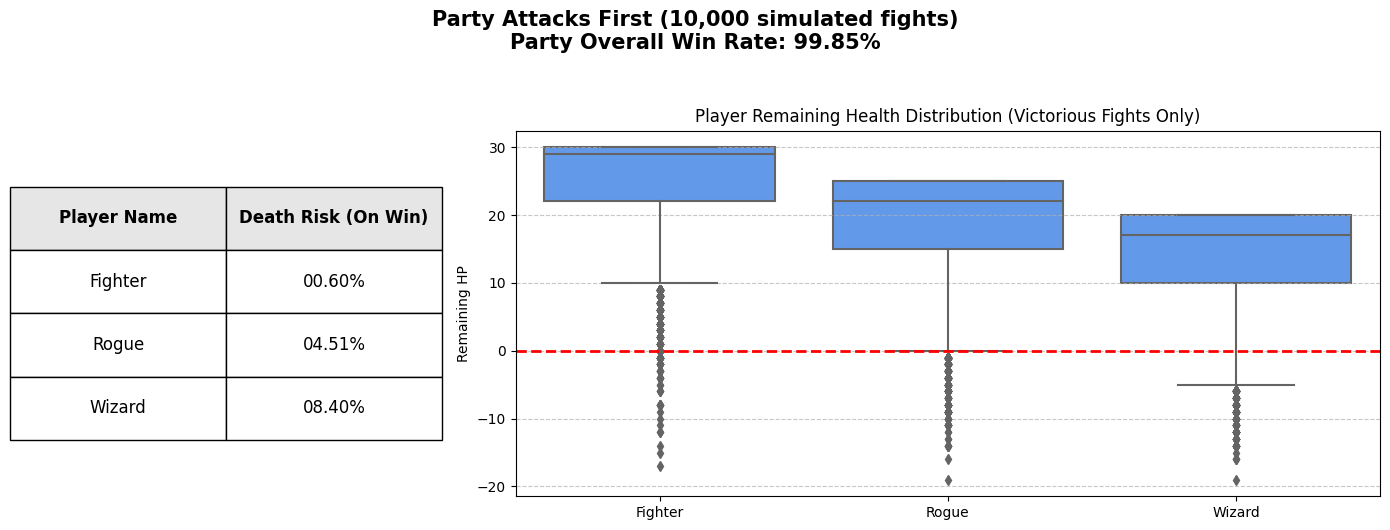


________________________________________________________________________________



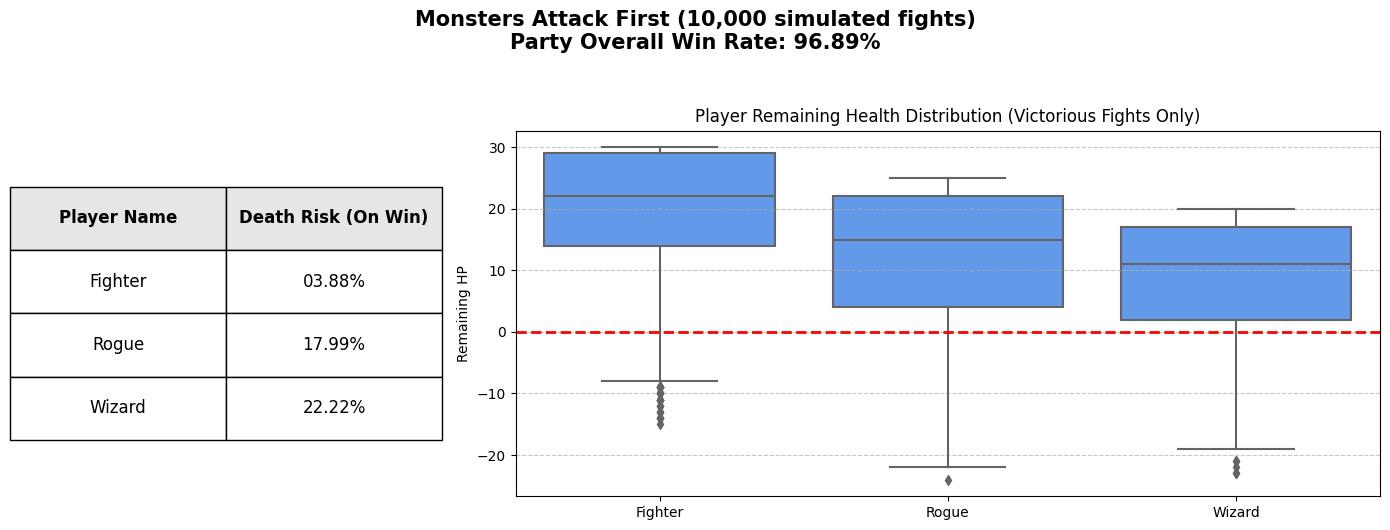

In [10]:
# --- CONFIGURE YOUR ENCOUNTER HERE ---
# DAMAGE: Can be Int (e.g. 5) or String (e.g. "5(3)" meaning 5 Base Damage to max 3 targets).
# PERFECT_TARGET (Players Only): 1 means ALWAYS targets highest HP alive enemy. 0 means random priority.
# MITIGATION: Flat integer subtraction from incoming hits.
party = [
    {'name': 'Fighter', 'dice': 3, 'target': 12, 'damage': 5, 'health': 30, 'mitigation': 2, 'perfect_target': 1},
    {'name': 'Rogue', 'dice': 3, 'target': 13, 'damage': 4, 'health': 25, 'mitigation': 0, 'perfect_target': 0},
    {'name': 'Wizard', 'dice': 4, 'target': 8, 'damage': "4(3)", 'health': 20, 'mitigation': 0, 'perfect_target': 1}
]

monsters = [
    {'name': 'Goblin A', 'dice': 2, 'target': 8, 'damage': 3, 'health': 10, 'mitigation': 1},
    {'name': 'Goblin B', 'dice': 2, 'target': 8, 'damage': 3, 'health': 10, 'mitigation': 1},
    {'name': 'Goblin C', 'dice': 2, 'target': 8, 'damage': 3, 'health': 10, 'mitigation': 1},
    {'name': 'Goblin Boss', 'dice': 3, 'target': 10, 'damage': 5, 'health': 20, 'mitigation': 3}
]

# focus_party = 80 means each player has an 80% chance to attack their primary target, 20% to hit random enemy
simulate_combat_party(party, monsters, focus_party=80.0, focus_monsters=50.0, num_simulations=10000)